In [1]:
import numpy as np
from baryrat import aaa
from surmof_cavity import ag_surmof_cavity_trref as transmission
import matplotlib.pyplot as plt
import matplotlib as mpl
from functools import partial
import contourint
import functools

In [2]:
material_poles = np.array([448.79110491874115, 438.2930673770547, 412.93727009075883])/300*2*np.pi

In [3]:
contour = contourint.Ellipse(center = material_poles[-1]-0.08-0.059j, radius=0.067+0.007j, num_points = 2048)
#contour = contourint.Ellipse(center = 15-1j, radius=14+2j, num_points = 2048)

In [10]:
all_poles = []
all_residues = []
ts = 0.025*(np.arange(28)+1)
npoles = 1
for thickness in ts[20:21]:
    #functools.lru_cache(maxsize=None)()
    f = partial(transmission, thickness=thickness, npoles=npoles)
    
    poles, residues = contourint.locate_poles(contour, f, M=6, cutoff=1e-30)
    all_poles.append(poles)
    all_residues.append(residues)

Ellipse(center=0j, radius=Array(2.64575131+0.37796447j, dtype=complex128, weak_type=True), num_points=2048)


In [11]:
all_residues

[Array([ 0.95720981-0.35125524j, -0.6996807 +0.35902749j,
         0.49144522-0.40109138j, -0.24296529+0.27982785j,
         0.03951331-0.07194671j, -0.00241356+0.00705507j],      dtype=complex128)]

In [12]:
all_poles

[Array([25.80280845-1.06824633j, 21.44978042-0.92533694j,
        16.87394347-0.58188382j, 13.86215518-0.69894007j,
         7.66941827-0.24488941j,  3.67527571-0.03621555j],      dtype=complex128)]

In [13]:
wfreqr1 = material_poles[-1] - np.logspace(-5, -1, 800) 

wfreqi = np.linspace(-0.05, -0.07, 60)

wfreqr = np.concatenate([wfreqr1 ,np.linspace(5, 30, 200)])
wfreqr = np.sort(wfreqr)

wfreqi = np.concatenate([wfreqi, np.linspace(-2, 0.2, 200)])
wfreqi = np.sort(wfreqi)

Wfreqr, Wfreqi = np.meshgrid(wfreqr, wfreqi, indexing='ij')
Wfreq = Wfreqr + 1j*Wfreqi

In [14]:
F = f(Wfreq)

Text(0, 0.5, '$\\Im\\{\\omega\\}$')

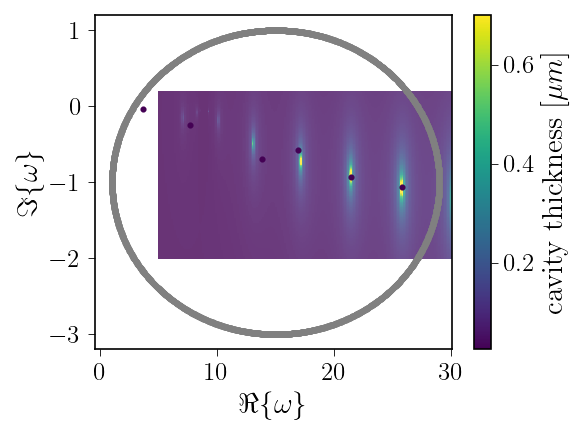

In [15]:
cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min(ts), vmax=max(ts))
colors = cmap(norm(ts))

plt.pcolormesh(Wfreqr, Wfreqi, np.abs(F), alpha=0.8, vmax = 1e1)
plt.scatter(contour.points.real, contour.points.imag, color="gray")
for color, poles in zip(colors, all_poles):
    filtered_poles = poles[poles.imag<-0.01]
    plt.scatter(filtered_poles.real, filtered_poles.imag, color=color)
plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=plt.gca(), label="cavity thickness [$\mu m$]")

plt.xlabel("$\Re\{\omega\}$")
plt.ylabel("$\Im\{\omega\}$")
# plt.xlim(3, 16)
# plt.ylim(-1, 0)
# plt.savefig("pole_movement.png", dpi=600)

# # plt.xlim(8.5, 9.7)
# # plt.ylim(-0.1, -0.05)
# # plt.savefig("pole_movement_gap.png", dpi=600)

# # plt.xlim(8.5, 8.66)
# # plt.ylim(-0.07, -0.05)
# # plt.savefig("pole_movement_zoom.png", dpi=600)

# plt.xlim(8.5, 8.65)
# plt.ylim(-0.07, -0.05)